# Basic Steps to be folowed
1. Importing required libraries
2. Load the data
3. Preprocess the data
4. Define the model
5. Compile the model
6. Fit the model
7. Evaluate

# 1. Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten

In [2]:
# Checking the versions of tensorflow and keras
print(tf.__version__)
print(keras.__version__)

2.12.0
2.12.0


- Always ensure that the versions of tensorflow and keras are compatible with one another.
- All the other modules should be made compatible with tensorflow and keras and not vice versa

# 2. Loading the MNIST Dataset

In [3]:
from keras.datasets import mnist

In [4]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

### Observations:
- Train data has 60000 images of 28x28 dimensions
- Test data has 10000 images of 28x28 dimensions
- The images are in black and white

In [7]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

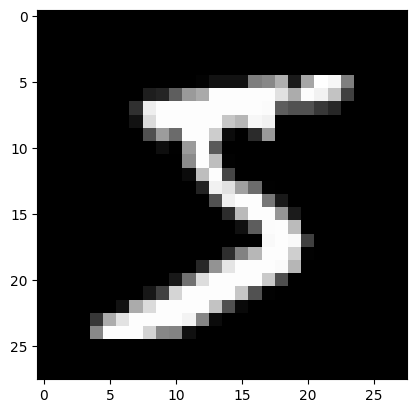

In [11]:
plt.imshow(x_train[0],cmap="gray")

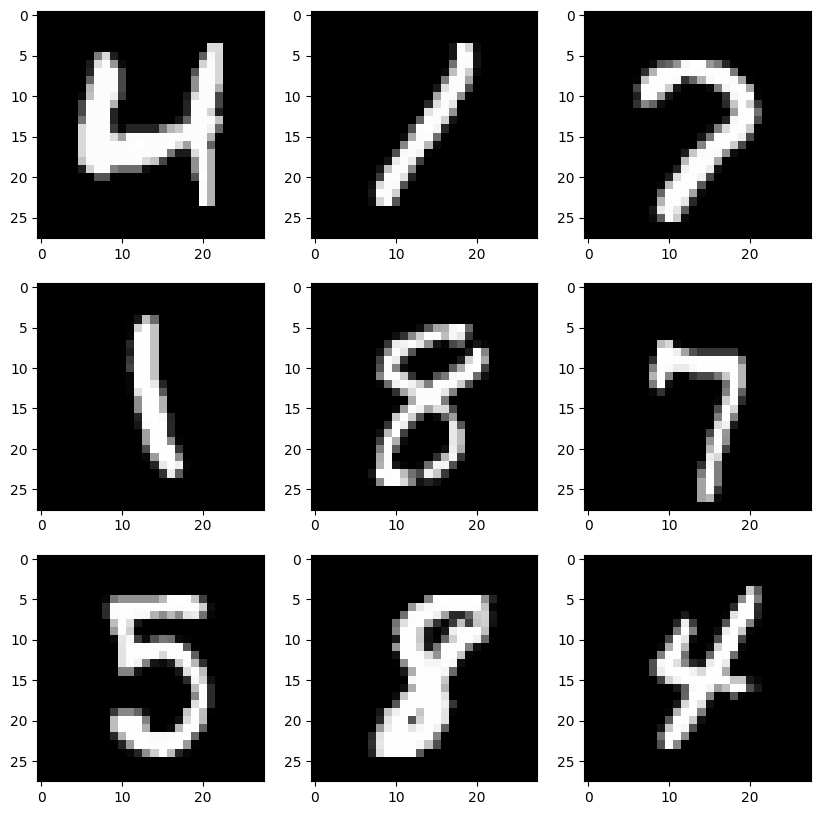

In [12]:
# Viewing few random images from the data
plt.figure(figsize=(10,10))
np.random.seed(0)
index = np.random.randint(0,60000,9)
for i in range(len(index)):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[index[i]],cmap="gray")

# 3. Data Preprocessing

In [13]:
# Min-Max Scaling without using any library
# x_min = 0   (The smallest pixel value)
# x_max = 255 (The largest pixel value)
# x/ x_max

x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [15]:
x_train_flattened = x_train_scaled.reshape(60000,784)
x_test_flattened = x_test_scaled.reshape(10000,784)

In [16]:
x_train_flattened.shape

(60000, 784)

In [18]:
# Converting the output to One Hot Encoding using np_utils from keras
y_train_encoded = np_utils.to_categorical(y_train,10)
y_test_encoded = np_utils.to_categorical(y_test,10)

In [19]:
print(y_train[0])
print(y_train_encoded[0])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# 4. Define the Model - Softmax Classifier

In [20]:
model = Sequential()
model.add(Dense(10,input_dim=784,activation="softmax"))

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                7850      
                                                                 
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
_________________________________________________________________


# 5. Compile the Model

In [22]:
model.compile(optimizer="sgd",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# 6. Fit the Model

In [23]:
model.fit(x_train_flattened,y_train_encoded,batch_size=128,epochs=10)

Epoch 1/10
469/469 [==============================] - 2s 2ms/step - loss: 1.2831 - accuracy: 0.6904
Epoch 2/10
469/469 [==============================] - 1s 2ms/step - loss: 0.7205 - accuracy: 0.8380
Epoch 3/10
469/469 [==============================] - 1s 2ms/step - loss: 0.5900 - accuracy: 0.8573
Epoch 4/10
469/469 [==============================] - 1s 2ms/step - loss: 0.5274 - accuracy: 0.8675
Epoch 5/10
469/469 [==============================] - 1s 2ms/step - loss: 0.4892 - accuracy: 0.8744
Epoch 6/10
469/469 [==============================] - 1s 2ms/step - loss: 0.4631 - accuracy: 0.8798
Epoch 7/10
469/469 [==============================] - 1s 2ms/step - loss: 0.4437 - accuracy: 0.8834
Epoch 8/10
469/469 [==============================] - 1s 2ms/step - loss: 0.4286 - accuracy: 0.8866
Epoch 9/10
469/469 [==============================] - 1s 2ms/step - loss: 0.4165 - accuracy: 0.8884
Epoch 10/10
469/469 [==============================] - 1s 2ms/step - loss: 0.4064 - accuracy: 0.8907

# 7. Evaluate the Model

In [24]:
model.evaluate(x_test_flattened,y_test_encoded)

313/313 [==============================] - 1s 2ms/step - loss: 0.3807 - accuracy: 0.8980


[0.3806982934474945, 0.8980000019073486]

In [25]:
model.evaluate(x_test_flattened,y_test_encoded,verbose=0)

[0.3806982934474945, 0.8980000019073486]